In [1]:
# Import du jeu de données Iris depuis scikit-learn
from sklearn.datasets import load_iris
iris = load_iris()

# On sélectionne TOUTES les lignes SAUF la dernière pour l'entraînement
# X contient les caractéristiques (features) des fleurs
X = iris.data[:-1, :]  # Toutes les colonnes, toutes les lignes sauf la dernière
# y contient les étiquettes (labels / classes) correspondantes
y = iris.target[:-1]    # Toutes les lignes sauf la dernière

# Import du modèle de régression logistique
from sklearn.linear_model import LogisticRegression

# Création d'une instance du modèle
logistic = LogisticRegression()

# Entraînement du modèle sur les données d'entraînement (X et y)
logistic.fit(X, y)

# Prédiction de la classe pour la dernière ligne (celle qu'on a exclue)
# .reshape(1, -1) est nécessaire car predict() attend un tableau 2D
single_row_pred = logistic.predict(
    iris.data[-1, :].reshape(1, -1))

# Prédiction des probabilités pour chaque classe (0, 1, 2)
single_row_pred_proba = logistic.predict_proba(
    iris.data[-1, :].reshape(1, -1))

# Affichage des résultats
# Classe prédite vs classe réelle
print('Predicted class %s, real class %s'
    % (single_row_pred, iris.target[-1]))

# Affichage des probabilités pour chaque classe
print('Probabilities for each class from 0 to 2: %s'
    % single_row_pred_proba)

# Sortie observée :
# Predicted class [2], real class 2
# Probabilities for each class from 0 to 2:
# [[0.00168787 0.28720074 0.71111138]]

Predicted class [2], real class 2
Probabilities for each class from 0 to 2: [[4.89299115e-04 2.45994936e-01 7.53515765e-01]]


In [7]:
import numpy as np

# fonction simplifiée d'un perceptron qui réalise la fonction logique OR
def perceptron(inputs, weights, threshold):
    assert len(inputs) == len(weights)
    # multiply the inputs and weights
    values = np.multiply(inputs, weights)
    # sum the results
    total = sum(values)
    # decide if we should activate the perceptron
    if total < threshold:
        return 0
    else:
        return 1

print("------------or------------")
# OR
inputs = [[0.0, 0.0], [1.0, 0.0], [0.0, 1.0], [1.0, 1.0]]
for input in inputs:
    print(input, perceptron(input, [0.5, 0.5], 0.5))

------------or------------
[0.0, 0.0] 0
[1.0, 0.0] 1
[0.0, 1.0] 1
[1.0, 1.0] 1


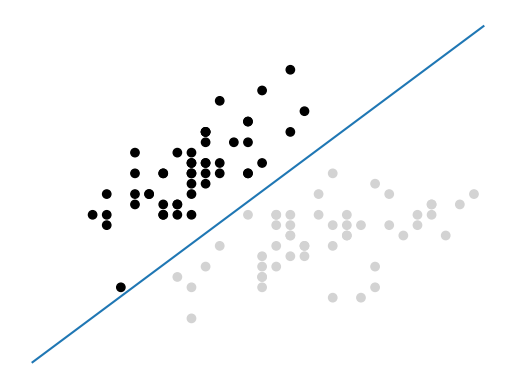

In [10]:
# Load libraries
from sklearn.svm import LinearSVC
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
import numpy as np
# Load data with only two classes and two features
iris = datasets.load_iris()
features = iris.data[:100,:2]
target = iris.target[:100]
# Standardize features
scaler = StandardScaler()
features_standardized = scaler.fit_transform(features)
# Create support vector classifier
svc = LinearSVC(C=1.0)
# Train model
model = svc.fit(features_standardized, target)

# Load library
from matplotlib import pyplot as plt
# Plot data points and color using their class
color = ["black" if c == 0 else "lightgrey" for c in target]
plt.scatter(features_standardized[:,0], features_standardized[:,1], c=color)
# Create the hyperplane
w = svc.coef_[0]
a = -w[0] / w[1]
xx = np.linspace(-2.5, 2.5)
yy = a * xx - (svc.intercept_[0]) / w[1]
# Plot the hyperplane
plt.plot(xx, yy)
plt.axis("off"), plt.show();

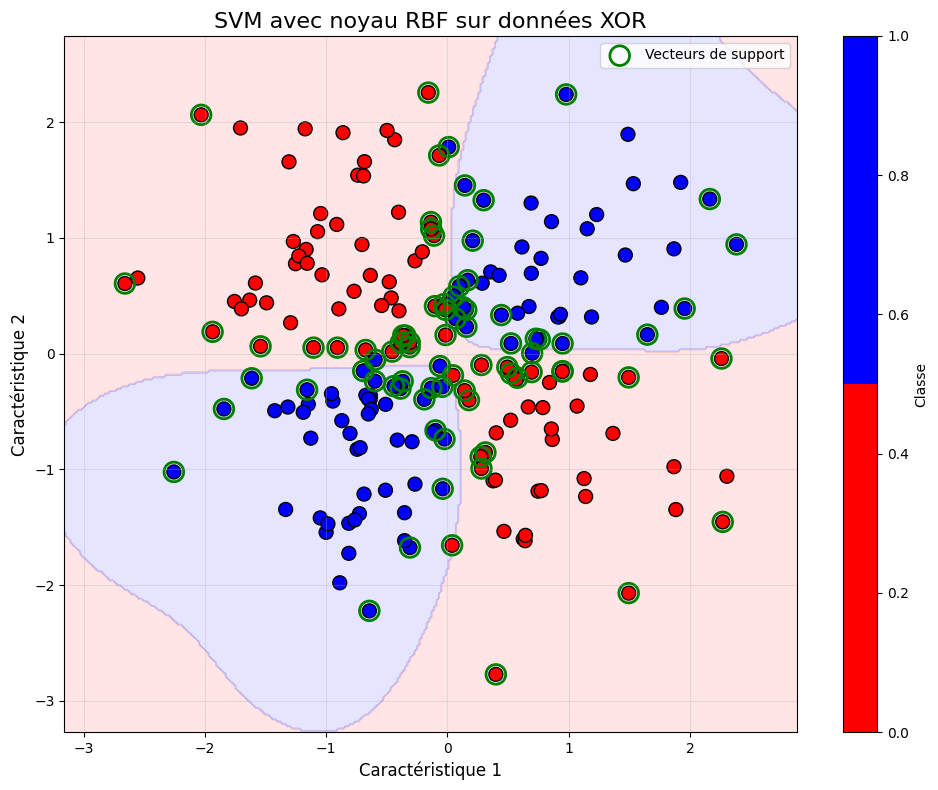

ANALYSE DU MODÈLE SVM
Précision du modèle: 96.50%
Nombre de vecteurs de support: 82
Kernel utilisé: rbf
Gamma: 1
C: 1

EXEMPLES DE PRÉDICTIONS
Point [1.5 1.5]: prédiction classe 1, distance à la frontière: 1.395
Point [-1.5 -1.5]: prédiction classe 1, distance à la frontière: 1.263
Point [ 1.5 -1.5]: prédiction classe 0, distance à la frontière: -1.438
Point [-1.5  1.5]: prédiction classe 0, distance à la frontière: -1.438


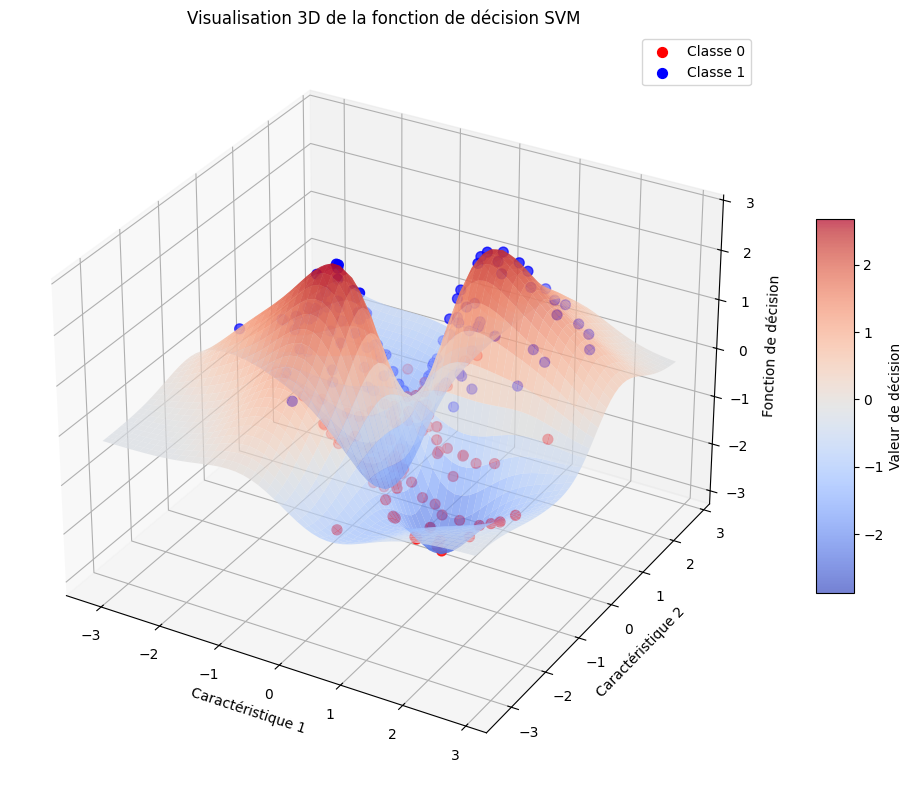

In [14]:
# Problème : nous souhaitons classifier des observations linéairement inséparables grâce à un SVM à noyaux
# Load libraries
from sklearn.svm import SVC
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Set randomization seed
np.random.seed(0)

# Generate two features
features = np.random.randn(200, 2)

# Use a XOR gate to generate linearly inseparable classes
target_xor = np.logical_xor(features[:, 0] > 0, features[:, 1] > 0)
target = np.where(target_xor, 0, 1)

# Create a support vector machine with a radial basis function kernel
svc = SVC(kernel="rbf", random_state=0, gamma=1, C=1)

# Train the classifier
model = svc.fit(features, target)

# ============================================
# VISUALISATION DU MODÈLE
# ============================================

def plot_decision_boundary(X, y, model, title):
    """
    Fonction pour visualiser la frontière de décision du SVM
    """
    # Création d'une grille de points pour visualiser la frontière
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # Création d'un maillage (mesh grid)
    h = 0.02  # pas du maillage
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Prédiction sur tous les points du maillage
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Création de la figure
    plt.figure(figsize=(10, 8))

    # Tracé de la frontière de décision
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))

    # Tracé des points de données
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y,
                          cmap=ListedColormap(['#FF0000', '#0000FF']),
                          edgecolors='black', s=100)

    # Identification des vecteurs de support
    plt.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=200, linewidth=2, facecolors='none',
                edgecolors='green', label='Vecteurs de support')

    plt.title(title, fontsize=16)
    plt.xlabel('Caractéristique 1', fontsize=12)
    plt.ylabel('Caractéristique 2', fontsize=12)
    plt.legend(loc='upper right')
    plt.colorbar(scatter, label='Classe')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Visualisation du modèle
plot_decision_boundary(features, target, model,
                      'SVM avec noyau RBF sur données XOR')

# ============================================
# ANALYSE DES RÉSULTATS
# ============================================

print("=" * 50)
print("ANALYSE DU MODÈLE SVM")
print("=" * 50)

# Précision du modèle
accuracy = model.score(features, target)
print(f"Précision du modèle: {accuracy:.2%}")

# Nombre de vecteurs de support
print(f"Nombre de vecteurs de support: {len(model.support_vectors_)}")

# Paramètres du modèle
print(f"Kernel utilisé: {model.kernel}")
print(f"Gamma: {model._gamma}")
print(f"C: {model.C}")

# Prédictions sur quelques exemples
print("\n" + "=" * 50)
print("EXEMPLES DE PRÉDICTIONS")
print("=" * 50)

# Exemples tests
test_points = np.array([[1.5, 1.5], [-1.5, -1.5], [1.5, -1.5], [-1.5, 1.5]])
for point in test_points:
    pred = model.predict([point])[0]
    proba = model.decision_function([point])[0]
    print(f"Point {point}: prédiction classe {pred}, distance à la frontière: {proba:.3f}")

# ============================================
# VISUALISATION 3D DE LA DÉCISION
# ============================================

def plot_3d_decision(X, y, model):
    """
    Visualisation 3D de la fonction de décision
    """
    from mpl_toolkits.mplot3d import Axes3D

    # Création du maillage
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                         np.linspace(y_min, y_max, 50))

    # Calcul de la fonction de décision pour le maillage
    Z_mesh = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z_mesh = Z_mesh.reshape(xx.shape)

    # Calcul de la fonction de décision pour les points de données réels
    Z_data = model.decision_function(X)

    # Création de la figure 3D
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Surface de décision
    surf = ax.plot_surface(xx, yy, Z_mesh, cmap='coolwarm', alpha=0.7, linewidth=0)

    # Points de données
    ax.scatter(X[y==0, 0], X[y==0, 1], Z_data[y==0], c='red', s=50, label='Classe 0')
    ax.scatter(X[y==1, 0], X[y==1, 1], Z_data[y==1], c='blue', s=50, label='Classe 1')

    ax.set_xlabel('Caractéristique 1')
    ax.set_ylabel('Caractéristique 2')
    ax.set_zlabel('Fonction de décision')
    ax.set_title('Visualisation 3D de la fonction de décision SVM')
    plt.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Valeur de décision')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Visualisation 3D
plot_3d_decision(features, target, model)


In [17]:
#Problème : nous souhaitons connaître la probabilité d’appartenance à chaque classe d’une nouvelle observation
# Load libraries
from sklearn.svm import SVC
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
import numpy as np
# Load data
iris = datasets.load_iris()
features = iris.data
target = iris.target
# Standardize features
scaler = StandardScaler()
features_standardized = scaler.fit_transform(features)
# Create support vector classifier object
svc = SVC(kernel="linear", probability=True, random_state=0)
# Train classifier
model = svc.fit(features_standardized, target)
# Create new observation
new_observation = [[.4, .4, .4, .4]]
# View predicted probabilities
model.predict_proba(new_observation)

array([[0.00541761, 0.97348825, 0.02109414]])

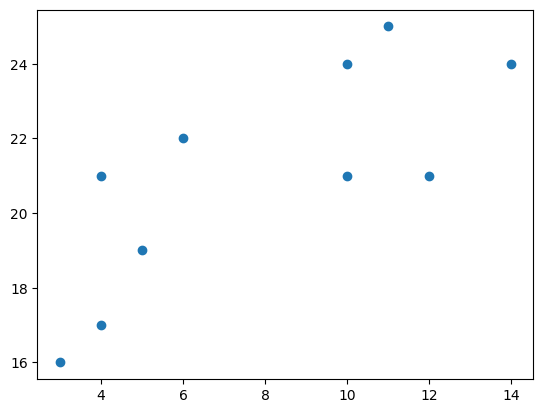

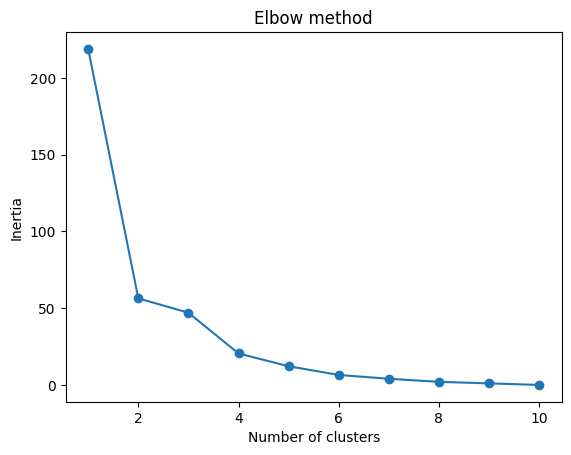

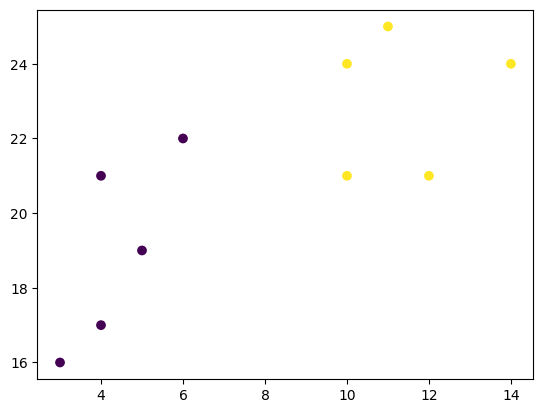

In [20]:
# Les K moyennes (K-means) : exemple
import matplotlib.pyplot as plt
x = [4, 5, 10, 4, 3, 11, 14 , 6, 10, 12]
y = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]
plt.scatter(x, y)
plt.show()
from sklearn.cluster import KMeans
data = list(zip(x, y))
inertias = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()
kmeans = KMeans(n_clusters=2)
kmeans.fit(data)
plt.scatter(x, y, c=kmeans.labels_)
plt.show()

In [21]:
''' Problème : Trouvons avec Python et la librairie Scikit-learn les K=2 plus proches voisins
d’une certaine observation [1, 1, 1, 1]'''
# Load libraries
from sklearn import datasets
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# Load data
iris = datasets.load_iris()
features = iris.data

# Create standardizer
standardizer = StandardScaler()
# Standardize features
features_standardized = standardizer.fit_transform(features)
# Two nearest neighbors
nearest_neighbors = NearestNeighbors(n_neighbors=2).fit(features_standardized)
# Create an observation
new_observation = [1, 1, 1, 1]

# Find distances and indices of the observation's nearest neighbors
distances, indices = nearest_neighbors.kneighbors([new_observation])
# View the nearest neighbors
features_standardized[indices]

array([[[1.03800476, 0.55861082, 1.10378283, 1.18556721],
        [0.79566902, 0.32841405, 0.76275827, 1.05393502]]])

In [22]:
# DBSCAN (Density-Based Spatial Clustering of Applications with Noise) : principe
# Note : les classes sont labellisées 0 et 1, et le label -1 indique les outliers.
# Load libraries
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
# Load data
iris = datasets.load_iris()
features = iris.data
# Standardize features
scaler = StandardScaler()
features_std = scaler.fit_transform(features)
# Create meanshift object
cluster = DBSCAN(n_jobs=-1)
# Train model
model = cluster.fit(features_std)
# Show cluster membership
model.labels_

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  1,
        1,  1,  1,  1,  1, -1, -1,  1, -1, -1,  1, -1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1, -1,  1,
        1,  1,  1, -1, -1, -1, -1, -1,  1,  1,  1,  1, -1,  1,  1, -1, -1,
       -1,  1,  1, -1,  1,  1, -1,  1,  1,  1, -1, -1, -1,  1,  1,  1, -1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1])

In [23]:
# Les Arbres de Décision : code Python pour de la classification
# Problème : nous voulons entraîner un modèle de classification en utilisant un arbre décisionnel.
# Load libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn import datasets
# Load data
iris = datasets.load_iris()
features = iris.data
target = iris.target
# Create decision tree classifier object
decisiontree = DecisionTreeClassifier(random_state=0)
# Train model
model = decisiontree.fit(features, target)


In [25]:
# Arbres de Décision avec California Housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import fetch_california_housing
import numpy as np

# Charger le dataset California Housing
housing = fetch_california_housing()
print(f"Description: {housing.DESCR[:500]}...")

# Sélectionner les 2 premières caractéristiques
features = housing.data[:, 0:2]  # MedInc (revenu médian) et HouseAge (âge des maisons)
target = housing.target

print(f"\nForme des données: {features.shape}")
print(f"Caractéristiques utilisées: {housing.feature_names[0:2]}")
print(f"Valeurs min/max des caractéristiques:\n Min: {features.min(axis=0)}\n Max: {features.max(axis=0)}")

# Créer et entraîner l'arbre de régression
decisiontree = DecisionTreeRegressor(random_state=0, max_depth=5)  # max_depth pour éviter le sur-apprentissage
model = decisiontree.fit(features, target)

# Évaluation rapide
score = model.score(features, target)
print(f"\nScore R² sur l'entraînement: {score:.3f}")

# Prédiction sur quelques exemples
print("\nPrédictions sur les 5 premiers échantillons:")
for i in range(5):
    pred = model.predict([features[i]])[0]
    print(f"  Échantillon {i}: prédiction = ${pred*100000:.0f}, réel = ${target[i]*100000:.0f}")



Description: .. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group popu...

Forme des données: (20640, 2)
Caractéristiques utilisées: ['MedInc', 'HouseAge']
Valeurs min/max des caractéristiques:
 Min: [0.4999 1.    ]
 Max: [15.0001 52.    ]

Score R² sur l'entraînement: 0.546

Prédictions sur les 5 premiers échantillons:
  Échantillon 0: prédiction = $476504, réel = $452600
  Échantillon 1: prédiction = $399102, réel = $358500
  Échantillon 2: prédiction = $427294, réel = $352100
  Échantillon 3: prédiction = $377551, réel = $341300
  Échantillon 4: pr

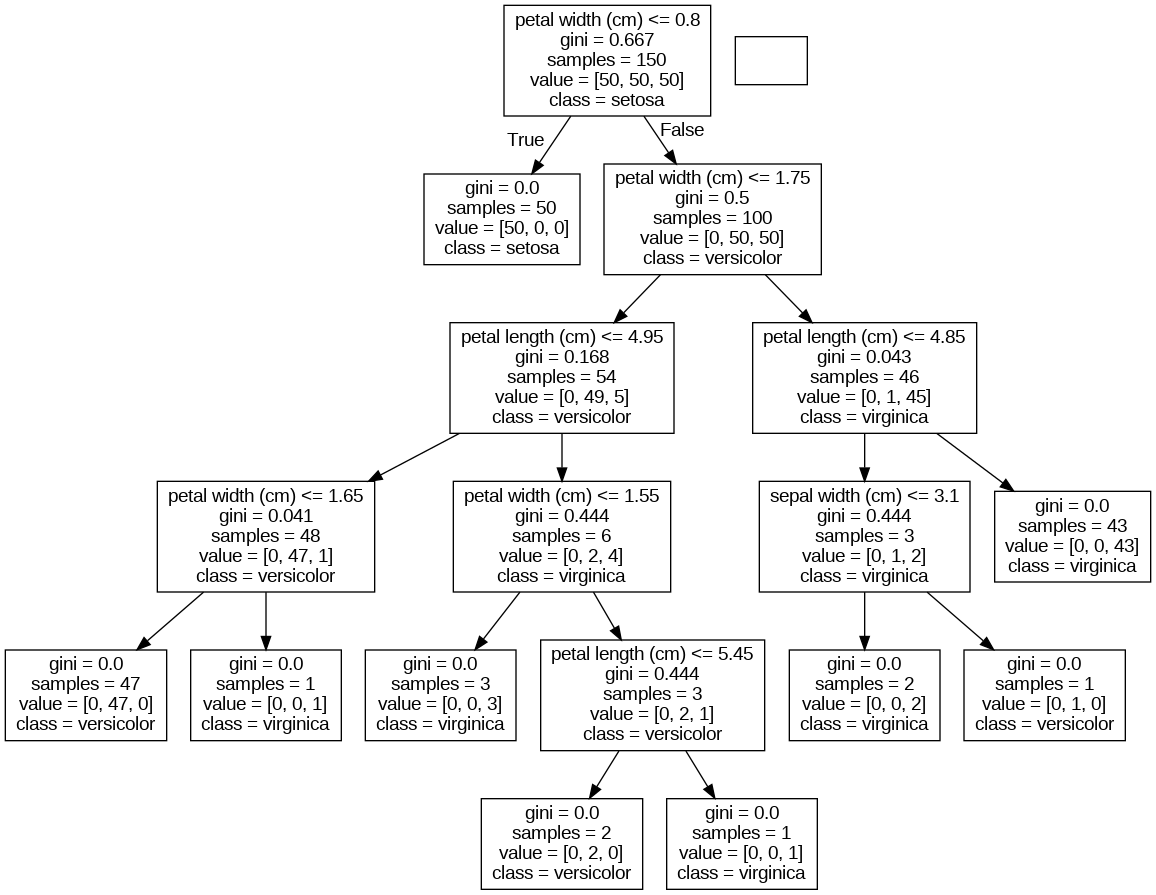

In [27]:
# NECESSITE L'INSTALLATION DE PYDOTPLUS:
pip install pydotplus
# Problème : nous voulons visualiser un arbre décisionnel
# Load libraries
import pydotplus
from sklearn.tree import DecisionTreeClassifier
from sklearn import datasets
from IPython.display import Image
from sklearn import tree
# Load data
iris = datasets.load_iris()
features = iris.data
target = iris.target
# Create decision tree classifier object
decisiontree = DecisionTreeClassifier(random_state=0)

# Train model
model = decisiontree.fit(features, target)
# Create DOT data
dot_data = tree.export_graphviz(decisiontree,
out_file=None,
feature_names=iris.feature_names,
class_names=iris.target_names)
# Draw graph
graph = pydotplus.graph_from_dot_data(dot_data)
# Show graph
Image(graph.create_png())


In [28]:
# Les Forets d’Arbres de Décision : code Python
# Problème : nous voulons entraîner un modèle de classification utilisant les forêts aléatoires.
# Load libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn import datasets
# Load data
iris = datasets.load_iris()
features = iris.data
target = iris.target
# Create random forest classifier object
randomforest = RandomForestClassifier(random_state=0, n_jobs=-1)
# Train model
model = randomforest.fit(features, target)

In [32]:
# Problème: nous voulons entraîner un modèle de régression utilisant les forêts aléatoires.

# Load libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import fetch_california_housing

# Load California housing data (alternative recommandée à Boston)
california = fetch_california_housing()

# Utiliser seulement les 2 premières caractéristiques
features = california.data[:, 0:2]  # MedInc (revenu médian) et HouseAge (âge des maisons)
target = california.target

# Afficher des informations sur les données
print("Jeu de données California Housing")
print(f"Nombre d'échantillons: {features.shape[0]}")
print(f"Caractéristiques utilisées: {california.feature_names[0:2]}")
print(f"Valeurs min/max des caractéristiques:\n Min: {features.min(axis=0)}\n Max: {features.max(axis=0)}")
print(f"Valeurs min/max de la cible (prix en $100k): {target.min():.2f} à {target.max():.2f}")

# Create random forest regressor object
# n_jobs=-1 utilise tous les processeurs disponibles
randomforest = RandomForestRegressor(
    random_state=0,
    n_jobs=-1,
    n_estimators=100,  # Nombre d'arbres dans la forêt (optionnel, 100 est la valeur par défaut)
    max_depth=10       # Limiter la profondeur pour éviter le sur-apprentissage (optionnel)
)

# Train model
model = randomforest.fit(features, target)

# Évaluation rapide du modèle
score = model.score(features, target)
print(f"\nScore R² sur l'entraînement: {score:.3f}")

# Importance des caractéristiques
print(f"\nImportance des caractéristiques:")
for i, feat_name in enumerate(california.feature_names[0:2]):
    print(f"  {feat_name}: {model.feature_importances_[i]:.3f}")

# Exemple de prédiction sur les 5 premiers échantillons
print(f"\nPrédictions sur les 5 premiers échantillons:")
for i in range(5):
    pred = model.predict([features[i]])[0]
    print(f"  Échantillon {i}: prédiction = ${pred*100000:.0f}, réel = ${target[i]*100000:.0f}")

Jeu de données California Housing
Nombre d'échantillons: 20640
Caractéristiques utilisées: ['MedInc', 'HouseAge']
Valeurs min/max des caractéristiques:
 Min: [0.4999 1.    ]
 Max: [15.0001 52.    ]
Valeurs min/max de la cible (prix en $100k): 0.15 à 5.00

Score R² sur l'entraînement: 0.632

Importance des caractéristiques:
  MedInc: 0.878
  HouseAge: 0.122

Prédictions sur les 5 premiers échantillons:
  Échantillon 0: prédiction = $478266, réel = $452600
  Échantillon 1: prédiction = $416942, réel = $358500
  Échantillon 2: prédiction = $423207, réel = $352100
  Échantillon 3: prédiction = $356188, réel = $341300
  Échantillon 4: prédiction = $285941, réel = $342200


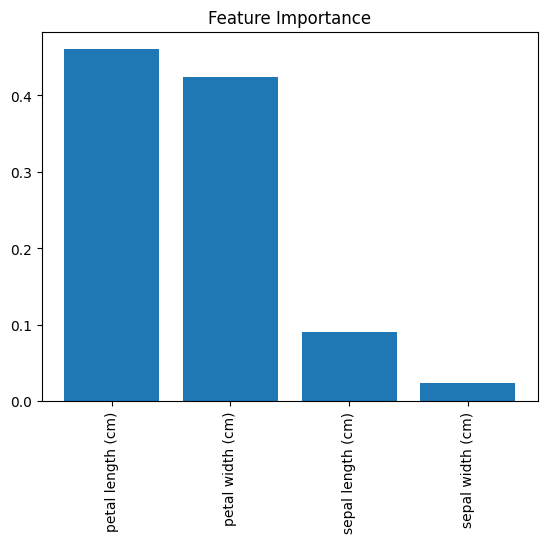

In [33]:
# Les Forets d’Arbres de Décision : code Python
# Problème : nous voulons identifier des attributs significatifs d’un modèle de classification utilisant les forêts aléatoires.
# Load libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn import datasets
# Load data
iris = datasets.load_iris()
features = iris.data
target = iris.target
# Create random forest classifier object
randomforest = RandomForestClassifier(random_state=0, n_jobs=-1)
# Train model
model = randomforest.fit(features, target)

# Calculate feature importances
importances = model.feature_importances_
# Sort feature importances in descending order
indices = np.argsort(importances)[::-1]
# Rearrange feature names so they match the sorted feature importances
names = [iris.feature_names[i] for i in indices]
# Create plot
plt.figure()
# Create plot title
plt.title("Feature Importance")
# Add bars
plt.bar(range(features.shape[1]), importances[indices])
# Add feature names as x-axis labels
plt.xticks(range(features.shape[1]), names, rotation=90)
# Show plot
plt.show()

In [35]:
# La Classification Naive Bayésienne : exemple 1 de code Python sur des données continues
# Load libraries
from sklearn import datasets
from sklearn.naive_bayes import GaussianNB
# Load data
iris = datasets.load_iris()
features = iris.data
target = iris.target
# Create Gaussian Naive Bayes object
classifer = GaussianNB()
# Train model
model = classifer.fit(features, target)
# Create new observation
new_observation = [[ 4, 4, 4, 0.4]]
# Predict class
model.predict(new_observation)
model.predict_proba(new_observation)

array([[1.34715602e-38, 9.99949727e-01, 5.02727760e-05]])

In [36]:
# La Classification Naive Bayésienne : exemple 2 de code Python sur des données discrètes
# Load libraries
import numpy as np
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
# Create text
text_data = np.array(['I love Brazil. Brazil!',
'Brazil is best',
'Germany beats both'])
# Create bag of words
count = CountVectorizer()
bag_of_words = count.fit_transform(text_data)
# Create feature matrix
features = bag_of_words.toarray()
# Create target vector
target = np.array([0,0,1])
# Create multinomial naive Bayes object with prior probabilities of each class
classifer = MultinomialNB(class_prior=[0.25, 0.5])
# Train model
model = classifer.fit(features, target)
# Create new observation
new_observation = [[0, 0, 0, 1, 0, 1, 0]]
# Predict new observation's class
model.predict(new_observation)
# Résultat : array([0])

array([0])

In [37]:
# La Classification Naive Bayésienne : exemple 3 de code Python sur des données binaires
# Load libraries
import numpy as np
from sklearn.naive_bayes import BernoulliNB
# Create three binary features
features = np.random.randint(2, size=(100, 3))
# Create a binary target vector
target = np.random.randint(2, size=(100, 1)).ravel()
# Create Bernoulli Naive Bayes object with prior probabilities of each class
classifer = BernoulliNB(class_prior=[0.25, 0.5])
# Train model
model = classifer.fit(features, target)
# Create new observation
new_observation = [[0, 0, 1]]
# Predict new observation's class
model.predict(new_observation)
# Résultat :  array([1])

array([1])

In [38]:
# La Classification Naive Bayésienne : exemple 4 de calibrage des résultats pour les rendre plus facilement interprétables
# Load libraries
from sklearn import datasets
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV
# Load data
iris = datasets.load_iris()
features = iris.data
target = iris.target
# Create Gaussian Naive Bayes object
classifer = GaussianNB()
# Create calibrated cross-validation with sigmoid calibration
classifer_sigmoid = CalibratedClassifierCV(classifer, cv=2, method='sigmoid')
# Calibrate probabilities
classifer_sigmoid.fit(features, target)
# Create new observation
new_observation = [[ 2.6, 2.6, 2.6, 0.4]]
# View calibrated probabilities
classifer_sigmoid.predict_proba(new_observation)
# Résultat : array([[ 0.31859969, 0.63663466, 0.04476565]])

array([[0.31859971, 0.63663451, 0.04476578]])

In [40]:
# Les Réseaux de Neurones : code Python corrigé
# Load libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras import models
from tensorflow.keras import layers

# Set random seed
np.random.seed(0)
tf.random.set_seed(0)

# Set the number of features we want
number_of_features = 1000

print("Chargement du dataset IMDB...")
# Load data and target vector from movie review data
(data_train, target_train), (data_test, target_test) = imdb.load_data(
    num_words=number_of_features)

print(f"Taille des données d'entraînement: {len(data_train)}")
print(f"Taille des données de test: {len(data_test)}")

# Convert movie review data to one-hot encoded feature matrix
print("Conversion des données en matrice one-hot...")
tokenizer = Tokenizer(num_words=number_of_features)
features_train = tokenizer.sequences_to_matrix(data_train, mode="binary")
features_test = tokenizer.sequences_to_matrix(data_test, mode="binary")

print(f"Forme des features d'entraînement: {features_train.shape}")

# Start neural network
network = models.Sequential()

# Add fully connected layer with a ReLU activation function
network.add(layers.Dense(units=16, activation="relu", input_shape=(
    number_of_features,)))

# Add fully connected layer with a ReLU activation function
network.add(layers.Dense(units=16, activation="relu"))

# Add fully connected layer with a sigmoid activation function
network.add(layers.Dense(units=1, activation="sigmoid"))

# Compile neural network
network.compile(loss="binary_crossentropy",  # Cross-entropy
                optimizer="rmsprop",         # Root Mean Square Propagation
                metrics=["accuracy"])        # Accuracy performance metric

print("\nArchitecture du réseau:")
network.summary()

# Train neural network
print("\nEntraînement du réseau...")
history = network.fit(features_train,      # Features
                      target_train,        # Target vector
                      epochs=3,             # Number of epochs
                      verbose=1,            # Print description after each epoch
                      batch_size=100,       # Number of observations per batch
                      validation_data=(features_test, target_test))  # Test data

# Évaluation finale
print("\nÉvaluation sur les données de test:")
test_loss, test_accuracy = network.evaluate(features_test, target_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Chargement du dataset IMDB...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Taille des données d'entraînement: 25000
Taille des données de test: 25000
Conversion des données en matrice one-hot...
Forme des features d'entraînement: (25000, 1000)

Architecture du réseau:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │        16,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,305 (63.69 KB)

 Trainable params: 16,305 (63.69 KB)

 Non-trainable params: 0 (0.00 B)


Entraînement du réseau...
Epoch 1/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7453 - loss: 0.5186 - val_accuracy: 0.8592 - val_loss: 0.3337
Epoch 2/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8635 - loss: 0.3301 - val_accuracy: 0.8607 - val_loss: 0.3278
Epoch 3/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8679 - loss: 0.3196 - val_accuracy: 0.8599 - val_loss: 0.3275

Évaluation sur les données de test:
Test Accuracy: 0.8599
Test Loss: 0.3275
